# Initialization

In [18]:
import pandas as pd
import itertools
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator
import sys

utils_path = r"C:\Users\awast\OneDrive\Desktop\MKM"
sys.path.append(utils_path)
import _plotting_defaults

In [19]:
# Experimental conditions (Pt50Ru50 HClO4) and constants

C_H_list = np.array([0.1, 0.25, 0.5, 1]) # in M 
P_CO_list = 0.01*np.array([0.1, 1, 10, 100]) # in atm 
trials = [1]
conditions = list(itertools.product(C_H_list, P_CO_list))
conditions_trials = list(itertools.product(C_H_list, P_CO_list, trials))

R, T, F = 8.3145, 293.15, 96485
n = 2 # number of electrons transferred in the reaction
slope_f = np.log(10) * R * T / F # Tafel slope factor in V/decade
 
number_of_points = 55 # For a dE of 0.01 V = 10 mV

# Fraction of max current which gets truncated. 0.01 for 1% cutoff. 
cutoff_limit = 0.01

gamma = 210e-6 / F # moles of Pt per cm2, 1cm2 Pt = 210 uC

In [20]:
# Load current density data + classification

excel_file = '../Summary_current_densities.xlsx'
df = pd.read_excel(excel_file, sheet_name='Pt50Ru50 HClO4', header=None)

experiments = {}
for c_idx, C_H in enumerate(C_H_list):
    for trial in trials:
        for p_idx, P_CO in enumerate(P_CO_list):
            i = c_idx * len(P_CO_list) + p_idx
            col_idx = i * 2
            subset = df.iloc[3:, col_idx : col_idx+2].copy()
            subset.columns = ['E', 'j']
            # Force numeric, coerce bad values to NaN, then drop
            subset['E'] = pd.to_numeric(subset['E'], errors='coerce')
            subset['j'] = pd.to_numeric(subset['j'], errors='coerce')
            subset = subset.dropna()
            experiments[(C_H, P_CO, trial)] = subset

# Smoothing and Interpolating

In [21]:
# Define common grid, interpolate and calculate averages

all_min_SHE = min(df['E'].min() + slope_f * np.log10(C) for (C, _, _), df in experiments.items())
all_max_SHE = max(df['E'].max() + slope_f * np.log10(C) for (C, _, _), df in experiments.items())
dE = (all_max_SHE - all_min_SHE) / (number_of_points - 1)
master_E_grid = np.arange(np.floor(all_min_SHE / dE) * dE, np.ceil(all_max_SHE / dE) * dE + dE, dE)
experiments_interp, experiments_mean, untruncated_data = {}, {}, {}

for P_CO in P_CO_list:
    for C_H in C_H_list:
        local_min_RHE = max(experiments[(C_H, P_CO, t)]['E'].min() for t in trials)
        local_max_RHE = min(experiments[(C_H, P_CO, t)]['E'].max() for t in trials)
        E_ref = slope_f * np.log10(C_H)
        mask = (master_E_grid >= (local_min_RHE + E_ref) - 1e-9) & (master_E_grid <= (local_max_RHE + E_ref) + 1e-9)
        E_grid_SHE = master_E_grid[mask]

        rate_fulls, log_rate_fulls, start_indices = [], [], []
        for trial in trials:
            cond = (C_H, P_CO, trial)
            df = experiments[cond]
            df_trunc = df[(df['E'] >= local_min_RHE) & (df['E'] <= local_max_RHE)]
            rate_interp = PchipInterpolator(df_trunc['E'] + E_ref, df_trunc['j'] / (1000 * n * F * gamma))(E_grid_SHE)
            valid = rate_interp > 0
            log_rate_interp = np.full_like(rate_interp, np.nan)
            log_rate_interp[valid] = np.log(rate_interp[valid])
            
            max_rate = np.max(rate_interp)
            valid_indices = np.where(rate_interp >= cutoff_limit * max_rate)[0]
            start_idx = valid_indices[0] if len(valid_indices) > 0 else 0
            
            start_indices.append(start_idx)
            rate_fulls.append(rate_interp)
            log_rate_fulls.append(log_rate_interp)
            
            untruncated_data[cond] = {
                'E': E_grid_SHE,
                'rate': rate_interp,
                'log_rate': log_rate_interp,
            }

        final_start = max(start_indices)
        E_final = E_grid_SHE[final_start:]
        rate_mat = [rate_full[final_start:] for rate_full in rate_fulls]
        log_rate_mat = [log_rate_full[final_start:] for log_rate_full in log_rate_fulls]

        for trial, rate_full, log_rate_full in zip(trials, rate_fulls, log_rate_fulls):
            cond = (C_H, P_CO, trial)
            r_final = rate_full[final_start:]
            lr_final = log_rate_full[final_start:]
            
            experiments_interp[cond] = {
                'E': E_final,
                'rate': r_final,
                'log_rate': lr_final,
                'j': r_final * (1000 * n * F * gamma), 
            }

        experiments_mean[(C_H, P_CO)] = {
            'truncated_E': E_final,
            'truncated_rate': np.mean(rate_mat, axis=0),
            'truncated_rate_SD': np.std(rate_mat, axis=0, ddof=1),
            'truncated_log_rate': np.mean(log_rate_mat, axis=0),
            'truncated_log_rate_SD': np.std(log_rate_mat, axis=0, ddof=1),
            'truncated_rate_matrix': rate_mat,
            'E': E_grid_SHE,
            'rate': np.mean(rate_fulls, axis=0),
            'rate_SD': np.std(rate_fulls, axis=0, ddof=1),
            'log_rate': np.mean(log_rate_fulls, axis=0),
            'log_rate_SD': np.std(log_rate_fulls, axis=0, ddof=1),
        }

c:\Users\awast\miniconda3\envs\jdftx_env\Lib\site-packages\numpy\_core\_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\awast\miniconda3\envs\jdftx_env\Lib\site-packages\numpy\_core\_methods.py:211: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


# Currents

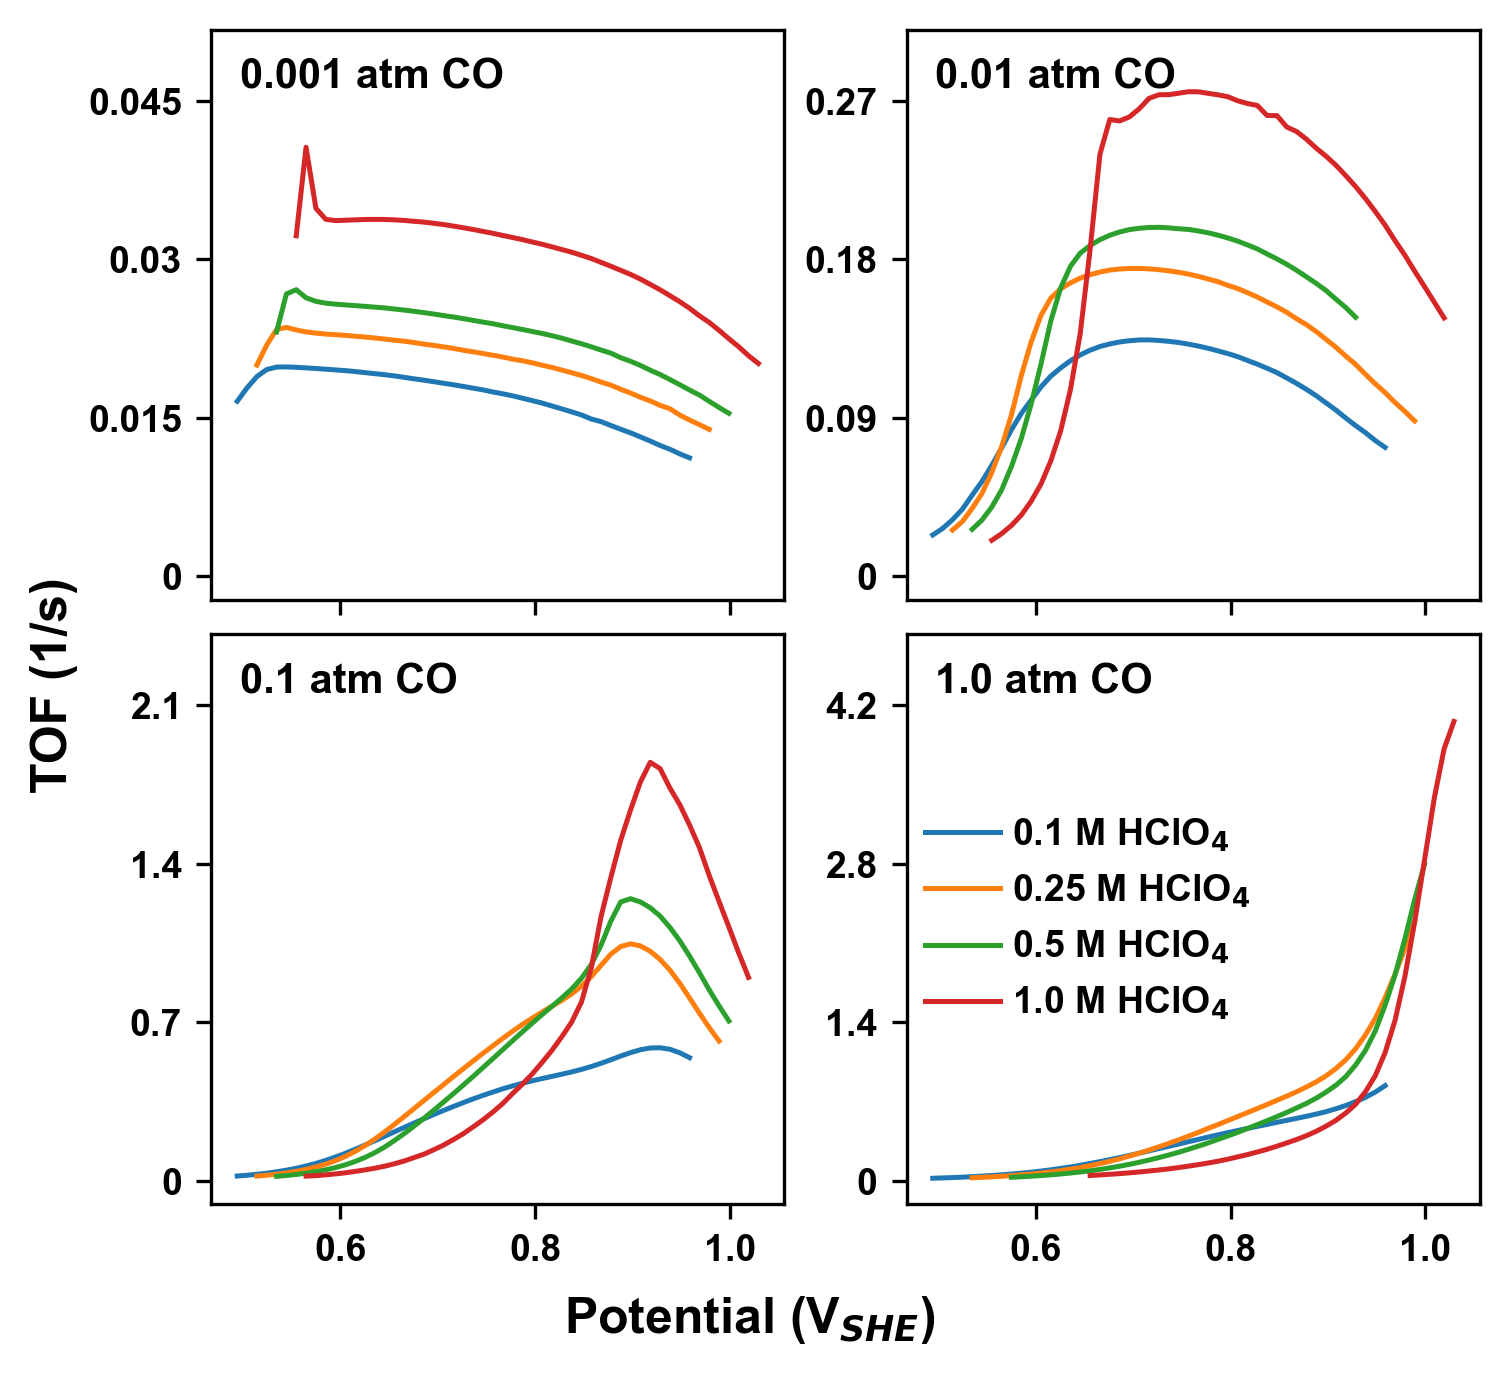

In [22]:
# Plot rates (TOF)

fig, axes = plt.subplots(2, 2, figsize=(5.0, 4.5), dpi=300, sharex=True)
axes = axes.flatten()
titles = ["0.001 atm CO", "0.01 atm CO", "0.1 atm CO", "1.0 atm CO"]
y_limits = {"0.001 atm CO": 0.045, "0.01 atm CO": 0.27, "0.1 atm CO": 2.1, "1.0 atm CO": 4.2}

for i, (ax, title_str) in enumerate(zip(axes, titles)):
    P_CO, y_max = P_CO_list[i], y_limits[titles[i]]

    for C_H in C_H_list:
        d = experiments_mean[(C_H, P_CO)]

        # Solid = truncated region used for fitting
        line, = ax.plot(d['truncated_E'], d['truncated_rate'], lw=1.2, label=f'{C_H} M HClO$_4$')
        color = line.get_color()
        ax.fill_between(
            d['truncated_E'],
            d['truncated_rate'] - d['truncated_rate_SD'],
            d['truncated_rate'] + d['truncated_rate_SD'],
            color=color,
            alpha=0.2,
        )

        # Dashed = truncated-off tail (untruncated data beyond truncated_E)
        if len(d['truncated_E']) > 0:
            mask = d['E'] <= np.min(d['truncated_E'])
            E_t, r_t = d['E'][mask], d['rate'][mask]
            err_t = d['rate_SD'][mask]

            # ax.plot(E_t, r_t, color=color, lw=1.2, ls='--', alpha=0.8)
            ax.fill_between(E_t, r_t - err_t, r_t + err_t, color=color, alpha=0.08)

    ticks = [0, y_max / 3, 2 * y_max / 3, y_max]
    ax.set_yticks(ticks)
    ax.set_yticklabels([f'{v:.3g}' for v in ticks])
    ax.set_ylim(-0.05 * y_max, y_max + (0.15 * y_max))
    ax.tick_params(labelsize=9)
    ax.text(0.05, 0.95, title_str, transform=ax.transAxes, fontsize=10, fontweight='bold', va='top')
    if i == 3:
        ax.legend(fontsize=9, frameon=False, loc='center left')

fig.supxlabel(r'Potential (V$_{SHE}$)', fontsize=12, fontweight='bold')
fig.supylabel('TOF (1/s)', fontsize=12, fontweight='bold')
plt.tight_layout(pad=0.4)
plt.show()

In [23]:
# Load Todd's alpha data + classification

# Directly loading the specific TCs file
tc_file = '../Summary_TCs.xlsx'
alpha_todd_raw = pd.read_excel(tc_file, sheet_name='Pt50Ru50 HClO4', header=None)
alpha_todd = {}

for i, (C_H, P_CO) in enumerate(conditions):
    col_idx = i * 2 # Only 2 columns per condition in this new spreadsheet (E and TC)
    subset = alpha_todd_raw.iloc[3:, col_idx : col_idx+2].copy()
    subset.columns = ['E', 'alpha'] # in RHE
    
    # Force numeric and drop NaNs
    subset['E'] = pd.to_numeric(subset['E'], errors='coerce')
    subset['alpha'] = pd.to_numeric(subset['alpha'], errors='coerce')
    subset = subset.dropna()
    
    # Shift to SHE for Acid
    E_ref = slope_f * np.log10(C_H)
    subset['E'] = subset['E'] + E_ref
    
    alpha_todd[(C_H, P_CO)] = subset

In [24]:
# Calculate alpha from UNTRUNCATED data for plotting reference

for condition_trial in conditions_trials:
    E = untruncated_data[condition_trial]['E']
    lnj = untruncated_data[condition_trial]['log_rate']

    alpha = (R*T/F)*np.gradient(lnj, E)    
    untruncated_data[condition_trial]['alpha'] = alpha

for condition in conditions:
    C_H, P_CO = condition
    alpha_trials = []
    for trial in trials:
        condition_trial = (C_H, P_CO, trial)
        alpha_trials.append(untruncated_data[condition_trial]['alpha'])
        
    alpha_array = np.array(alpha_trials)
    experiments_mean[condition]['alpha'] = np.mean(alpha_array, axis=0)
    experiments_mean[condition]['alpha_SD'] = np.zeros_like(experiments_mean[condition]['alpha'])

# Transfer Coefficients

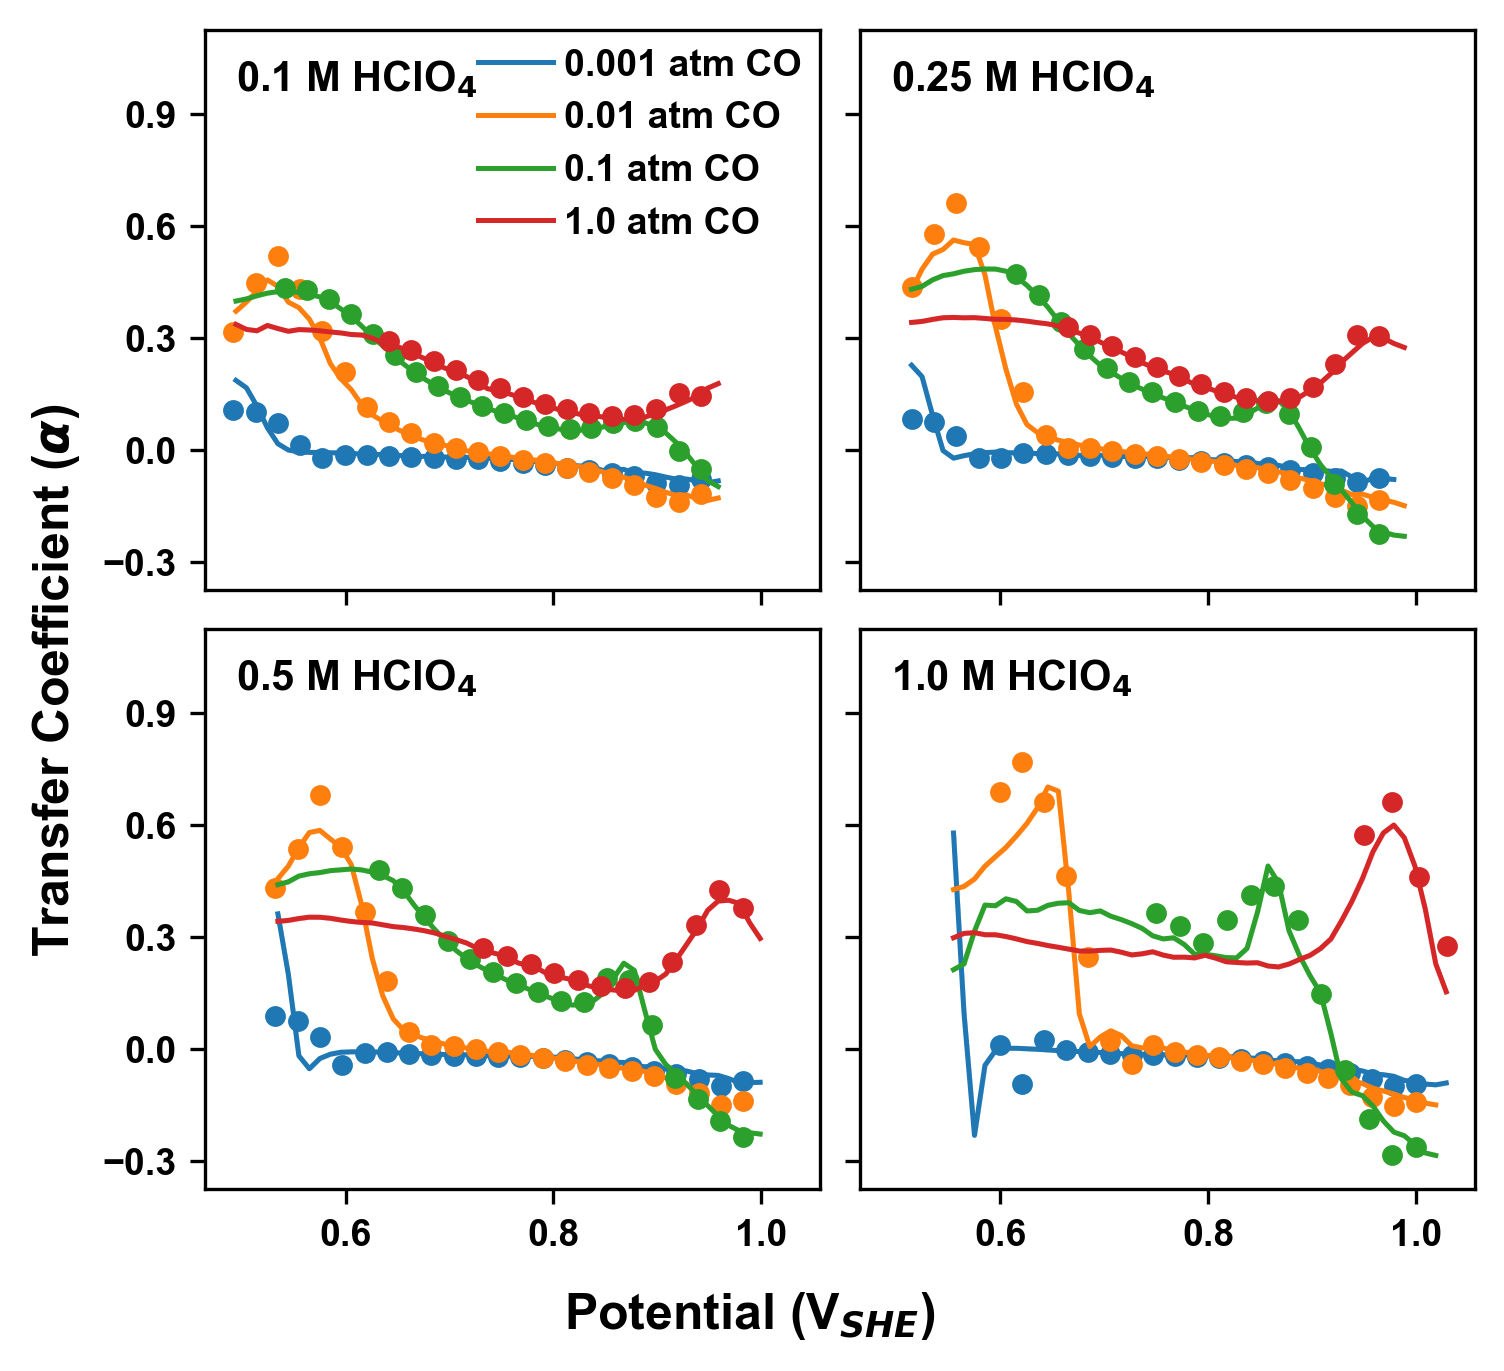

In [25]:
# Plotting alphas 

fig, axes = plt.subplots(2, 2, figsize=(5.0, 4.5), dpi=300, sharex=True, sharey=True)
axes = axes.flatten()

for i, (ax, C_H) in enumerate(zip(axes, C_H_list)):
    for P_CO in P_CO_list:
        cond = (C_H, P_CO)
        d = experiments_mean[cond]
        
        # Plot our calculated alphas
        line, = ax.plot(d['E'], d['alpha'], lw=1.2, label=f'{P_CO} atm CO')
        color = line.get_color()
        ax.fill_between(d['E'], d['alpha'] - d['alpha_SD'], 
                        d['alpha'] + d['alpha_SD'], color=color, alpha=0.2)
        
        # Overlay Todd's alphas as dots (no error bars since no replicates)
        t = alpha_todd[cond]
        ax.plot(t['E'], t['alpha'], 'o', markersize=4, color=color)

    span = 1.5
    ax.set_yticks([-0.3, 0.0, 0.3, 0.6, 0.9])
    ax.set_ylim(-0.3 - (0.05 * span), 0.9 + (0.15 * span)) 
    ax.tick_params(labelsize=9)
    
    ax.text(0.05, 0.95, f'{C_H} M HClO$_4$', transform=ax.transAxes, fontsize=10, fontweight='bold', va='top')
    if i == 0: ax.legend(fontsize=9, frameon=False, loc='upper right')

fig.supxlabel(r'Potential (V$_{SHE}$)', fontsize=12, fontweight='bold')
fig.supylabel(r'Transfer Coefficient ($\alpha$)', fontsize=12, fontweight='bold')
plt.tight_layout(pad=0.5)
plt.show()

In [26]:
# Load Todd's delta_H data + classification

ph_file = '../Summary_pH_order.xlsx'
delta_H_todd_raw = pd.read_excel(ph_file, sheet_name='Pt50Ru50 HClO4', header=None)
delta_H_todd = {}

for i, P_CO in enumerate(P_CO_list):
    col_idx = i * 2 # 2 columns per condition (E, H+ order)
    subset = delta_H_todd_raw.iloc[3:, col_idx : col_idx+2].copy()
    subset.columns = ['E', 'delta_H'] # in SHE
    subset['E'] = pd.to_numeric(subset['E'], errors='coerce')
    subset['delta_H'] = pd.to_numeric(subset['delta_H'], errors='coerce')
    subset = subset.dropna()
    
    delta_H_todd[P_CO] = subset

In [27]:
# Calculate delta_H from UNTRUNCATED data for plotting reference

for P_CO in P_CO_list:
    for trial in trials:
        common_E = None
        for C_H in C_H_list:
            E_SHE = untruncated_data[(C_H, P_CO, trial)]['E']
            if common_E is None: common_E = set(np.round(E_SHE, 6))
            else: common_E = common_E.intersection(np.round(E_SHE, 6))
        common_E = np.sort(list(common_E))
        
        log_rate_matrix = []
        for C_H in C_H_list:
            E_SHE = np.round(untruncated_data[(C_H, P_CO, trial)]['E'], 6)
            lr = untruncated_data[(C_H, P_CO, trial)]['log_rate']
            mask = np.isin(E_SHE, common_E)
            log_rate_matrix.append(lr[mask])
        log_rate_matrix = np.array(log_rate_matrix) 
        
        delta_H = np.polyfit(np.log(C_H_list), log_rate_matrix, deg=1)[0]
        
        for C_H in C_H_list: 
            untruncated_data[(C_H, P_CO, trial)]['delta_H'] = delta_H 
            untruncated_data[(C_H, P_CO, trial)]['common_E_H'] = common_E

for condition in conditions: 
    C_H, P_CO = condition
    delta_H_trials = [untruncated_data[(C_H, P_CO, trial)]['delta_H'] for trial in trials]
    delta_H_array = np.array(delta_H_trials)
    experiments_mean[condition]['E_H'] = untruncated_data[(C_H, P_CO, 1)]['common_E_H'] 
    experiments_mean[condition]['delta_H'] = np.mean(delta_H_array, axis=0) 
    experiments_mean[condition]['delta_H_SD'] = np.zeros_like(experiments_mean[condition]['delta_H'])

# H Reaction Order

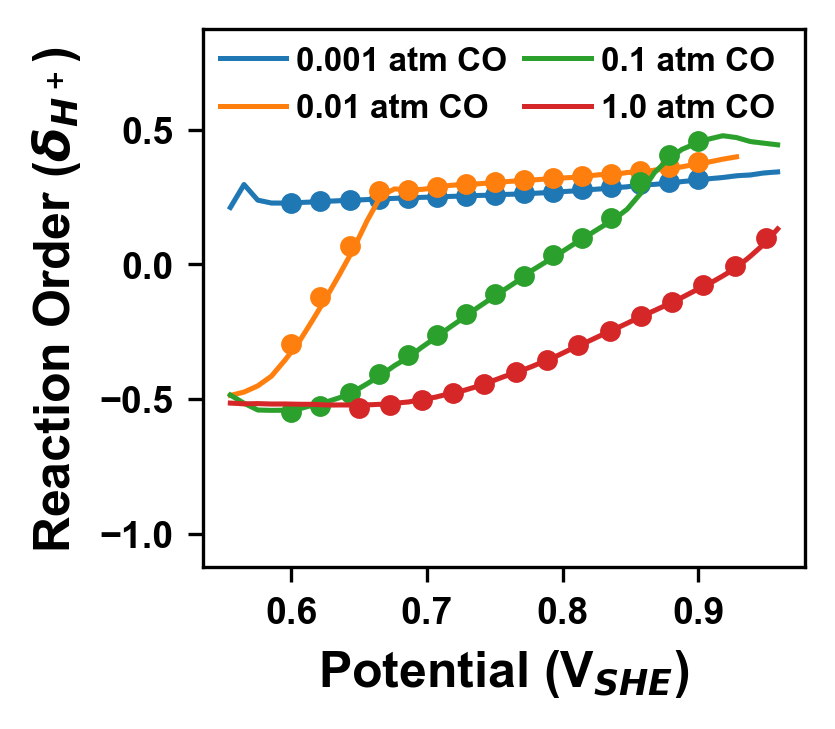

In [28]:
# Plotting delta_H

fig = plt.figure(figsize=(2.75, 2.4), dpi=300)
ax = plt.subplot(1, 1, 1)

for P_CO in P_CO_list:
    d = experiments_mean[(C_H_list[0], P_CO)]
    line, = ax.plot(d['E_H'], d['delta_H'], lw=1.2, label=f'{P_CO} atm CO')
    color = line.get_color()
    
    ax.fill_between(d['E_H'], d['delta_H'] - d['delta_H_SD'], 
                    d['delta_H'] + d['delta_H_SD'], color=color, alpha=0.2)
    
    t = delta_H_todd[P_CO]
    ax.plot(t['E'], t['delta_H'], 'o', markersize=4, color=color) # Todd's points as scatters

span = 2.5 
ax.set_yticks([-1.0, -0.5, 0.0, 0.5])
ax.set_ylim(-1.0 - (0.05 * span), 0.5 + (0.15 * span))
ax.tick_params(labelsize=9)
ax.set_xlabel(r'Potential (V$_{SHE}$)', fontsize=12, fontweight='bold')
ax.set_ylabel(r'Reaction Order ($\delta_{H^+}$)', fontsize=12, fontweight='bold')
ax.legend(fontsize=8, frameon=False, loc='upper left', ncol=2, columnspacing=0.5)
plt.tight_layout(pad=0.5)
plt.show()

In [29]:
# Load Todd's delta_CO data + classification

co_file = '../Summary_CO_order.xlsx'
delta_CO_todd_raw = pd.read_excel(co_file, sheet_name='Pt50Ru50 HClO4', header=None)
delta_CO_todd = {}
conditions_delta_CO = list(itertools.product(C_H_list, P_CO_list[0:-1]))

for i, (C_H, P_CO) in enumerate(conditions_delta_CO):
    col_idx = i * 2 # 2 columns per condition (E, CO Order)
    subset = delta_CO_todd_raw.iloc[3:, col_idx : col_idx+2].copy()
    subset.columns = ['E', 'delta_CO'] # in RHE
    
    subset['E'] = pd.to_numeric(subset['E'], errors='coerce')
    subset['delta_CO'] = pd.to_numeric(subset['delta_CO'], errors='coerce')
    subset = subset.dropna()
    
    # Shift RHE to SHE for Acid
    E_ref = slope_f * np.log10(C_H)
    subset['E'] = subset['E'] + E_ref
    
    delta_CO_todd[(C_H, P_CO)] = subset

In [30]:
# Calculate delta_CO from UNTRUNCATED data for plotting reference

for C_H in C_H_list:
    for trial in trials: 
        for i in range(len(P_CO_list) - 1):
            P_CO_1 = P_CO_list[i]
            P_CO_2 = P_CO_list[i+1]
            E_1 = np.round(untruncated_data[(C_H, P_CO_1, trial)]['E'], 6)
            E_2 = np.round(untruncated_data[(C_H, P_CO_2, trial)]['E'], 6)
            common_E = np.intersect1d(E_1, E_2)
            mask_1 = np.isin(E_1, common_E)
            mask_2 = np.isin(E_2, common_E)
            ln_j_1 = untruncated_data[(C_H, P_CO_1, trial)]['log_rate'][mask_1]
            ln_j_2 = untruncated_data[(C_H, P_CO_2, trial)]['log_rate'][mask_2]
            
            delta_CO = (ln_j_2 - ln_j_1) / np.log(P_CO_2 / P_CO_1)
            
            untruncated_data[(C_H, P_CO_1, trial)]['delta_CO'] = delta_CO
            untruncated_data[(C_H, P_CO_1, trial)]['common_E_CO'] = common_E

for C_H in C_H_list:
    for i in range(len(P_CO_list) - 1):
        P_CO_1 = P_CO_list[i]
        condition = (C_H, P_CO_1)
        delta_CO_trials = [untruncated_data[(C_H, P_CO_1, trial)]['delta_CO'] for trial in trials]
        delta_CO_array = np.array(delta_CO_trials)
        experiments_mean[condition]['E_CO'] = untruncated_data[(C_H, P_CO_1, 1)]['common_E_CO']
        experiments_mean[condition]['delta_CO'] = np.mean(delta_CO_array, axis=0) 
        experiments_mean[condition]['delta_CO_SD'] = np.zeros_like(experiments_mean[condition]['delta_CO'])

# CO Reaction Order

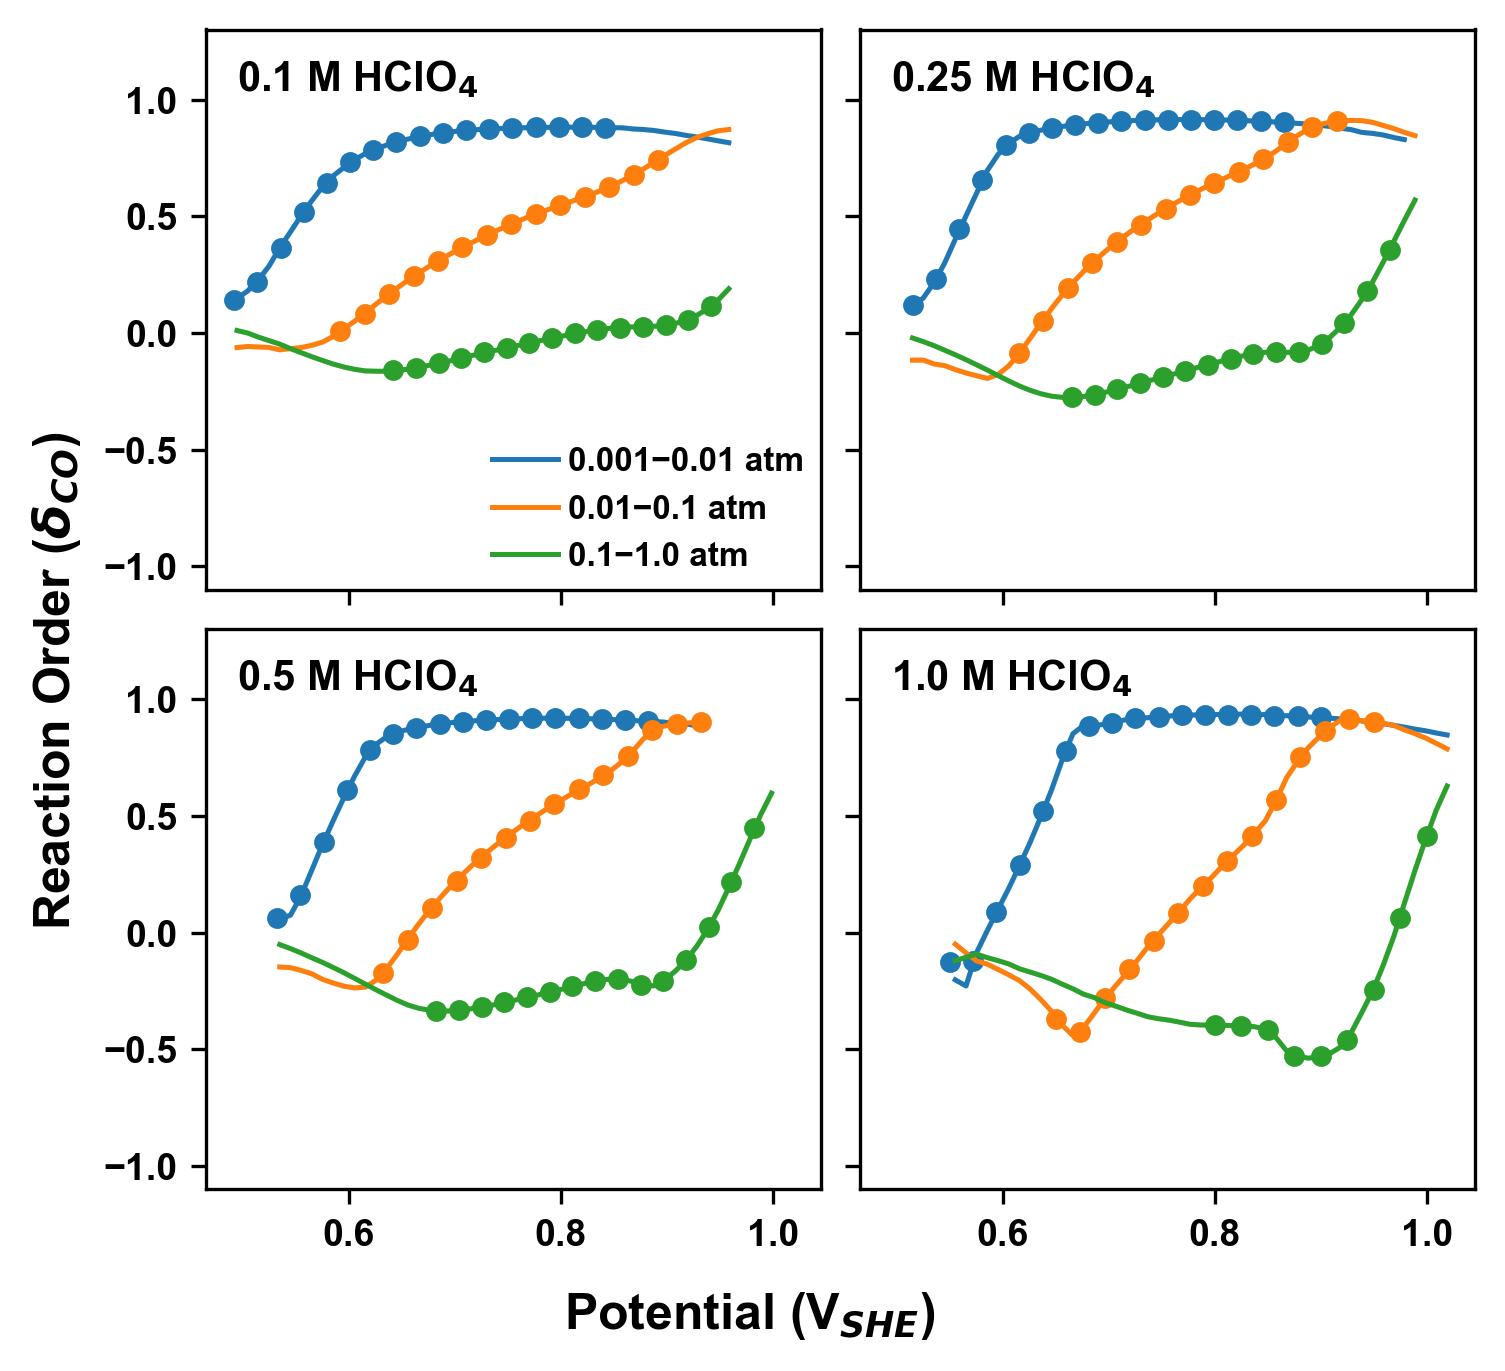

In [31]:
# Plotting delta_CO

fig, axes = plt.subplots(2, 2, figsize=(5.0, 4.5), dpi=300, sharex=True, sharey=True)
axes = axes.flatten()

for i, (ax, target_H) in enumerate(zip(axes, C_H_list)):
    for (C_H, P_CO) in [c for c in conditions_delta_CO if c[0] == target_H]:
        d = experiments_mean[(C_H, P_CO)]
        idx = np.where(P_CO_list == P_CO)[0][0]
        label_str = f'{P_CO}-{P_CO_list[idx+1]} atm'
        
        line, = ax.plot(d['E_CO'], d['delta_CO'], lw=1.2, label=label_str)
        color = line.get_color()
        ax.fill_between(d['E_CO'], d['delta_CO'] - d['delta_CO_SD'], 
                        d['delta_CO'] + d['delta_CO_SD'], color=color, alpha=0.2)
        
        t = delta_CO_todd[(C_H, P_CO)]
        ax.plot(t['E'], t['delta_CO'], 'o', markersize=4, color=color) # Todd's points

    span = 2.0 
    ax.set_yticks([-1.0, -0.5, 0.0, 0.5, 1.0])
    ax.set_ylim(-1 - (0.05 * span), 1 + (0.15 * span))
    ax.tick_params(labelsize=9)
    ax.text(0.05, 0.95, f'{target_H} M HClO$_4$', transform=ax.transAxes, fontsize=10, fontweight='bold', va='top')
    if i == 0: ax.legend(fontsize=8, frameon=False, loc='lower right')

fig.supxlabel(r'Potential (V$_{SHE}$)', fontsize=12, fontweight='bold')
fig.supylabel(r'Reaction Order ($\delta_{CO}$)', fontsize=12, fontweight='bold')
plt.tight_layout(pad=0.5)
plt.show()

In [32]:
import pickle

with open('import_Pt50Ru50_acid.pkl', 'wb') as f:
    pickle.dump(experiments_mean, f)

In [33]:
dE

np.float64(0.010090364893983359)